In [3]:

import sys
import os
# Add parent directory ('notebooks') to the search path
sys.path.append(os.path.abspath(os.path.join('..')))



from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message


## Single Node Graph

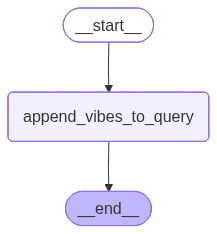

In [ ]:
# --- State Definition ---
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str




# --- Node Function ---
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": f"{state.message} {state.vibe}"
    }



# --- Graph Construction ---
workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)


graph = workflow.compile()



# --- Display Graph ---
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# Test 1
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling like a badass today!"
}

result = graph.invoke(initial_state)
print(result)
# Output:
# {'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}




{'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}


In [6]:
# Test 2 (Demonstrating answer state overwriting)
initial_state = {
    "message": "Give me some vibes!",
    "answer": "abc",
    "vibe": "I'm feeling like a badass today!"
}

result = graph.invoke(initial_state)
print(result)
# Output:
# {'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}

{'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}


## Conditional Graph

In [11]:
# --- State Definition ---
class State(BaseModel):
    message: str
    answer: str = ""


# --- Node Functions ---
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": "I am here to add some vibes:"
    }


# --- Router ---
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:
    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]
    vibe_path = random.choice(vibes)
    return vibe_path


# --- Conditional Node Functions ---
def append_vibe_1(state: State) -> dict:
    vibe = "I'm feeling like a badass today!"
    return {
        "answer": f"{state.answer} {vibe}"
    }

def append_vibe_2(state: State) -> dict:
    vibe = "I'm feeling like a boss today!"
    return {
        "answer": f"{state.answer} {vibe}"
    }

def append_vibe_3(state: State) -> dict:
    vibe = "I'm feeling like a legend today!"
    return {
        "answer": f"{state.answer} {vibe}"
    }


# --- Graph Construction ---
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

# Add routing decision based on router function output
workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge(START, "append_vibes_to_query")

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()


In [29]:
initial_state = {
    "message": "I am here to add some vibes:",
}

# Run invocation (routes to a random vibe)
result = graph.invoke(initial_state)
print(result)


{'message': 'I am here to add some vibes:', 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}


## Agent Graph

In [77]:
# --- Tool Definition ---
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.
    
    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.
        
    Returns:
        A string with the query and vibe appended.
    """
    return f"{query} {vibe}"





In [78]:
# --- Get Tool Descriptions ---
# This uses the utility function we wrote to parse the docstrings and signature
get_tool_descriptions([append_vibes])

[{'name': 'append_vibes',
  'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'The query to append the vibe to.'},
    'vibe': {'type': 'string',
     'description': 'The vibe to append to the query.'}}},
  'required': ['query', 'vibe'],
  'returns': {'type': 'string',
   'description': 'A string with the query and vibe appended.'}}]

In [63]:
# --- State and Tool Schema Models ---
class ToolCall(BaseModel):
    name: str
    arguments: dict


# The Response Model utilized by Instructor (GPT-4o-mini structured output)
class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = []


class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [ ]:


# --- Agent Node ---
def agent_node(state: State) -> dict:
    
    prompt_template = """You are an assistant that is generating vibes for a user.

You will be given a selection of tools you can use to add vibes to a user's query.

<Available tools>
{{ available_tools | tojson }}
</Available tools>

When you need to use a tool, format your response as:

<tool_call>
{"name": "tool_name", "arguments": {...}}
</tool_call>

Instructions:
- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
"""
    
    template = Template(prompt_template)
    
    prompt = template.render(
        available_tools=state.available_tools
    )
    
    client = instructor.from_openai(OpenAI())
    
    # NOTE: The model in the screenshot is written as "gpt-4.1-mini" which has a typo.
    # You should use the correct OpenAI model identifier "gpt-4o-mini".
    response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4o-mini",
        response_model=AgentResponse,
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": state.message}
        ],
        temperature=0.5,
    )

    print(response)
    print(raw_response)
    
    ai_message = format_ai_message(response)
    
    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls
    }


## Short Message Explaination

In [66]:
# --- Define a Conversation List ---
# Open AI Compatible Messages
conversation = [
    {'role': 'user', 'content': 'Give me some vibes!'},
    {'role': 'assistant', 'content': 'I am here to add some vibes:'},
    {'role': 'user', 'content': 'I am feeling like a badass today!'}
]

In [80]:
# --- Test LangChain Message Conversions ---
convert_to_messages(conversation)
# Expected Output:
# [HumanMessage(content='Give me some vibes!'), AIMessage(content='I am here to add some vibes:'), HumanMessage(content='I am feeling like a badass today!')]


[HumanMessage(content='Give me some vibes!', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I am feeling like a badass today!', additional_kwargs={}, response_metadata={})]

In [82]:
# --- Test OpenAI Message Conversion ---
convert_to_openai_messages(convert_to_messages(conversation))
# Expected Output:
# [{'role': 'user', 'content': 'Give me some vibes!'}, {'role': 'assistant', 'content': 'I am here to add some vibes:'}, {'role': 'user', 'content': 'I am feeling like a badass today!'}]


[{'role': 'user', 'content': 'Give me some vibes!'},
 {'role': 'assistant', 'content': 'I am here to add some vibes:'},
 {'role': 'user', 'content': 'I am feeling like a badass today!'}]

In [83]:
# --- Test AgentResponse & ToolCall Schema Construction ---
dummy_response = AgentResponse(
    answer="I am here to add some vibes:", 
    tool_calls=[
        ToolCall(
            name="append_vibes", 
            arguments={
                "query": "Give me some vibes!", 
                "vibe": "I am feeling like a badass today!"
            }
        )
    ]
)

In [84]:
dummy_response
# Expected Output:
# AgentResponse(answer='I am here to add some vibes:', tool_calls=[ToolCall(name='append_vibes', arguments={'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'})])


AgentResponse(answer='I am here to add some vibes:', tool_calls=[ToolCall(name='append_vibes', arguments={'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'})])

In [85]:

# --- Test AI Message Formatting Function ---
format_ai_message(dummy_response)
# Expected Output:
# AIMessage(content='I am here to add some vibes:', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'}, 'id': 'call_0', 'type': 'tool_call'}])


AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'I am feeling like a badass today!'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])

## End of Explanation

In [86]:
def tool_router(state: State) -> str:
    """Decide whether to continue or end"""
    
    if len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"


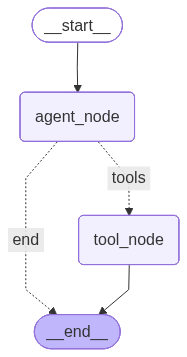

In [87]:
workflow = StateGraph(State)

# Change this:
# tools = ToolNode[append_vibes]

# To this:
tools = [append_vibes]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)



workflow.add_node("agent_node",agent_node)
workflow.add_node("tool_node",tool_node)


workflow.add_edge(START,"agent_node")
workflow.add_conditional_edges("agent_node",
tool_router,{
    "tools":"tool_node",
    "end": END
})


workflow.add_edge("tool_node",END)


graph = workflow.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [88]:
# --- Define Initial State with the User's Message and Tools ---
initial_state = {
    "message": "Give me some vibes!",
    "available_tools": tool_descriptions
}

# --- Invoke the Graph ---
result = graph.invoke(initial_state)

# --- Display Output ---
result


ValueError: Invalid format specifier ' "tool_name", "arguments": Ellipsis' for object of type 'str'

In [ ]:
result

{'messages': [AIMessage(content='Here are some vibes for you: 🌟✨', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'message': 'Give me some vibes!',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'The query to append the vibe to.'},
     'vibe': {'type': 'string',
      'description': 'The vibe to append to the query.'}}},
   'required': ['query', 'vibe'],
   'returns': {'type': 'string',
    'description': 'A string with the query and vibe appended.'}}],
 'tool_calls': []}